# 05 — Sequential Pattern Mining

The idea: turn each child's continuous activity trace into a short word made of
three letters — **L**ow, **M**edium, **H**igh activity — then ask which letter
sequences show up often, and which show up in one class but not the other.

Unlike the classifiers in notebook 04, the output here is meant to be read
rather than scored: a pattern like `L -> L -> L -> L -> L -> L` describes 30
hours of uninterrupted low activity, which is a statement about behaviour.

Equivalent to: `python main.py --stage patterns`

In [1]:
# Make the project's src/ package importable from inside notebooks/.
import os
import sys
sys.path.insert(0, os.path.abspath(".."))

import warnings
warnings.filterwarnings("ignore")

from src.config import PATHS, SPM_CHANNEL
from src.sequential_patterns import (discretize_sequences,
                                     plot_contrast_patterns,
                                     print_contrast_report,
                                     print_pattern_interpretation,
                                     print_symbol_distribution,
                                     report_global_patterns,
                                     run_contrast_mining)
from src.utils import load_prepared_arrays

## 1. Load the `enmo` channel

Sequential pattern mining uses `enmo` alone: it is the direct measure of how
much a child is moving, which is what the L/M/H symbols are meant to describe.

In [2]:
X_train, _, y_train, _ = load_prepared_arrays()

enmo = X_train[:, :, SPM_CHANNEL]
print(f"Loaded {enmo.shape[0]} subjects.")

Loaded 3549 subjects.


## 2. Discretisation

Two steps. First PAA: each block of 10 consecutive time steps collapses to its
mean, cutting 200 steps to 20 and smoothing away noise. Then binning: the 33rd
and 66th percentiles of *all* block averages across *all* subjects become the
two cut points.

Using global rather than per-subject cut points is the important choice — it is
what makes an "H" mean the same thing for every child, and it makes the three
symbols equally frequent overall by construction.

In [3]:
sequences, quantiles = discretize_sequences(enmo)

Computed Quantiles:
  Low threshold (<33%): -0.3673
  High threshold (>66%): 0.0215
Discretized 3549 sequences of length 20.

Sample sequence:
L -> M -> H -> H -> M -> M -> M -> H -> H -> H -> H -> H -> H -> H -> M -> L -> M -> M -> M -> L


A first, crude check for signal. If both classes had identical symbol mixes, no
pattern built from those symbols could possibly separate them — so the skew
below (problematic children spend more time in L, less in H) is what makes the
rest of the notebook worth running.

In [4]:
print_symbol_distribution(sequences, y_train)


=== Global symbol distribution across all sequences ===
  L: 23658 (33.3%)
  M: 23664 (33.3%)
  H: 23658 (33.3%)

=== Symbol distribution by SII class ===
  Sym  |   SII=0 (non-prob) |  SII=1 (problematic)
  L    |   14555 ( 30.8%) |    9103 ( 38.4%)
  M    |   15418 ( 32.6%) |    8246 ( 34.8%)
  H    |   17327 ( 36.6%) |    6331 ( 26.7%)


## 3. Global patterns with GSP

GSP starts from single frequent symbols and grows patterns one symbol at a
time, keeping only those that clear the support bar.

Two settings shape the result:

- **`max_gap = 1`** means pattern elements must be strictly **contiguous** in
  time. "Low, then low, then low" describes three consecutive blocks, not three
  low blocks scattered across the day.
- **20% minimum support** is low by Apriori standards, but the contiguity
  constraint makes matching much stricter, so a higher bar returns almost
  nothing.

**Maximal patterns only.** Every sub-pattern of a frequent pattern is itself
frequent, so the raw output is dominated by fragments of a handful of long
patterns. Keeping only the maximal ones removes that redundancy without losing
information — here it cuts 70 raw patterns down to 29.

In [5]:
maximal_global = report_global_patterns(sequences)

Running contiguous GSP (max_gap=1) with minimum support: 20%
Extracted 70 raw frequent patterns.
Reduced to 29 Maximal Sequential Patterns in 2.73 seconds.

Top 10 Most Supported Contiguous Maximal Patterns:
  M -> M -> L               | Supp: 36.4% (n=1291)
  M -> L -> L               | Supp: 33.7% (n=1196)
  H -> M -> M -> M          | Supp: 33.0% (n=1171)
  M -> M -> M -> M          | Supp: 31.4% (n=1113)
  M -> H -> H -> M          | Supp: 29.6% (n=1049)
  L -> M -> M -> M          | Supp: 29.2% (n=1036)
  M -> L -> M               | Supp: 28.7% (n=1017)
  M -> H -> M -> M          | Supp: 28.1% (n=998)
  M -> H -> H -> H -> H -> H | Supp: 27.9% (n=990)
  M -> M -> H -> H -> H     | Supp: 27.6% (n=981)

=== Maximal pattern length distribution ===
  Length 3: 7 patterns
  Length 4: 10 patterns
  Length 5: 7 patterns
  Length 6: 5 patterns
  Longest pattern: length 6
  Shortest pattern: length 3

=== All maximal patterns (sorted by support) ===
  M -> M -> L                         |

## 4. Contrast mining: SII = 0 vs SII = 1

A pattern that is frequent in both cohorts describes ordinary childhood and
tells us nothing. The interesting patterns are those that clear the support bar
in one cohort and not the other, so each class is mined separately and the
results are differenced.

- **SII = 0** — non-problematic internet use.
- **SII = 1** — problematic (originally mild, moderate or severe).

In [6]:
unique_to_0, unique_to_1, support_0, support_1, _, _ = run_contrast_mining(
    sequences, y_train)

top_class0, top_class1 = print_contrast_report(unique_to_0, unique_to_1,
                                               support_0, support_1)

Cohort sizes:
  SII=0 (Non-problematic): 2365
  SII=1 (Problematic):     1184

Running Contiguous GSP (min_sup=20%, max_gap=1)...
Maximal patterns found:
  SII=0: 28
  SII=1: 28

Discriminative Maximal Patterns:
  Unique to SII=0: 19
  Unique to SII=1: 19

=== Top discriminative patterns unique to SII=0 (non-problematic) ===
  M -> H -> H -> H -> H -> H -> H     | support in SII=0: 22.6%
  H -> H -> H -> H -> H -> M          | support in SII=0: 26.5%
  H -> M -> H -> H -> H -> H          | support in SII=0: 20.8%
  M -> M -> H -> H -> H -> H          | support in SII=0: 20.6%
  H -> H -> M -> H -> H               | support in SII=0: 26.8%
  H -> H -> H -> M -> H               | support in SII=0: 26.0%
  L -> L -> L -> M -> M               | support in SII=0: 25.0%
  H -> H -> H -> M -> M               | support in SII=0: 23.7%
  M -> M -> M -> H -> H               | support in SII=0: 23.6%
  L -> L -> L -> M -> H               | support in SII=0: 21.3%

=== Top discriminative patterns 

## 5. Visualising the discriminative patterns

Patterns are ranked by length first, then by support: a long contiguous pattern
describes a longer stretch of sustained behaviour, which is the interesting
signal here. The x-axis starts at the minimum support rather than at zero, so
differences between patterns that all cleared the same bar stay visible.

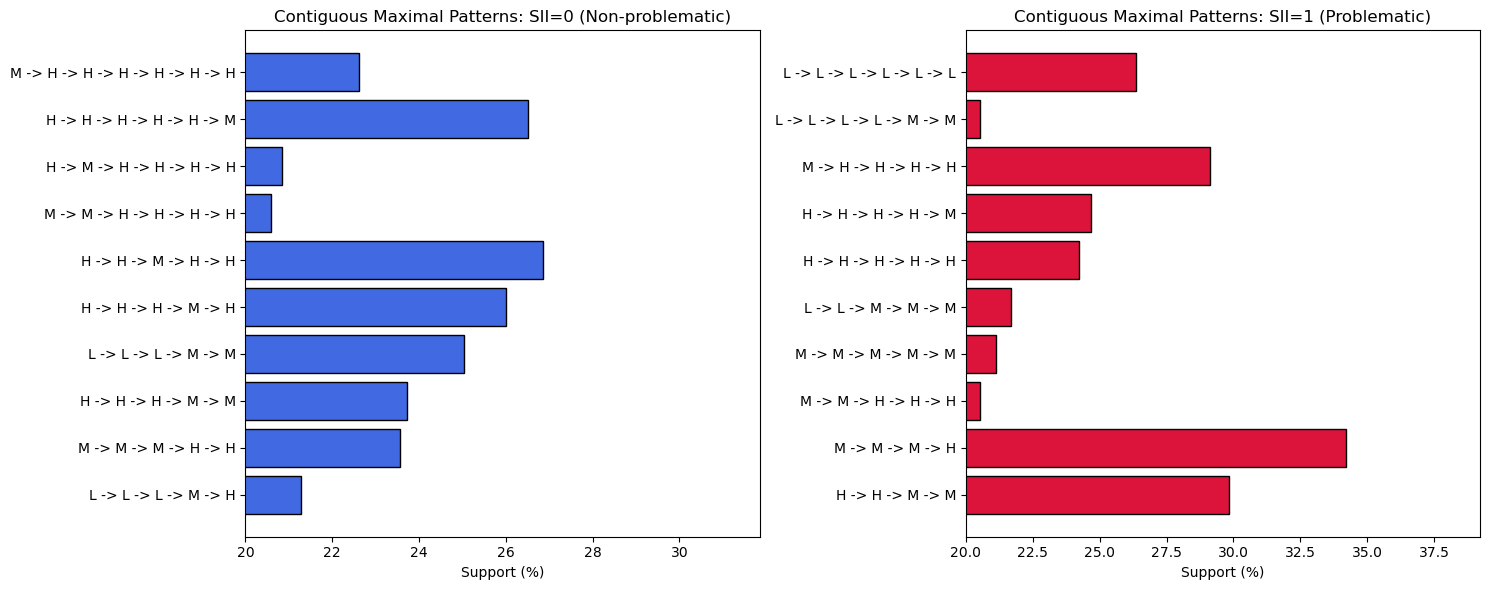

In [7]:
import os

os.makedirs(PATHS["figures_dir"], exist_ok=True)
plot_contrast_patterns(
    top_class0, top_class1, support_0, support_1,
    os.path.join(PATHS["figures_dir"], "07_spm_contrast_patterns.png"))

## 6. Interpretation

Each symbol covers 10 time steps of 30 minutes — five hours — so a six-symbol
pattern describes a genuinely long stretch of uninterrupted behaviour rather
than a momentary dip.

In [8]:
print_pattern_interpretation(top_class0, top_class1, support_0, support_1,
                             quantiles)


=== Computed interpretation of discriminative patterns ===
  Longest SII=1-unique pattern: 'L -> L -> L -> L -> L -> L'
  Length: 6 segments × 300 min/segment = 30.0h of continuous behaviour
  Support: 26.4% of problematic children show this pattern

  Longest SII=0-unique pattern: 'M -> H -> H -> H -> H -> H -> H'
  Length: 7 segments × 300 min/segment = 35.0h of continuous behaviour
  Support: 22.6% of non-problematic children show this pattern

  Quantile thresholds: L < -0.3673 g  ≤  M < 0.0215 g  ≤  H (ENMO in raw units)


## What to take from this

The clearest behavioural finding in the whole project, and the most readable:

- The **problematic** group is uniquely characterised by sustained unbroken
  chains of low activity — `L -> L -> L -> L -> L -> L`, 30 continuous hours,
  in 26.4% of them.
- The **non-problematic** group is uniquely characterised by extended high
  activity, `M -> H -> H -> H -> H -> H -> H`, in 22.6% of them.

Both supports sit near the 20% floor, so these describe a minority of children
in each group rather than a rule. The direction is consistent with everything
else in the project — less movement, more problematic use — but the pattern is
a population-level description, not an individual diagnostic.